# Cliff Walking com Q-Learning Tabular e Aproximação Linear

Este notebook implementa o problema **Cliff Walking** conforme o Exemplo 6.6 de Sutton & Barto. O objetivo é treinar um agente para sair do estado inicial, alcançar o objetivo e evitar o precipício, comparando duas abordagens de aprendizado por reforço:

- **Q-Learning tabular**, no qual cada par estado-ação possui um valor próprio em uma tabela `Q(s,a)`.
- **Q-Learning com aproximação linear e semi-gradiente**, no qual `Q(s,a,w) = w^T phi(s,a)` substitui a tabela por uma função parametrizada.

A implementação é feita do zero, sem Gym, Gymnasium ou bibliotecas prontas de aprendizado por reforço. O notebook documenta a dinâmica do ambiente, os agentes, as métricas de treinamento e a comparação final exigida pela rubrica.

## Importações

As bibliotecas usadas são deliberadamente simples. `numpy` é usado para vetores, tabelas e operações numéricas; `matplotlib` é usado para visualizar o gridworld, as curvas de aprendizado, as políticas e as funções de valor. As estruturas `dataclass` e `IntEnum` ajudam a manter o código organizado e explícito.

In [16]:
from __future__ import annotations

from dataclasses import dataclass
from enum import IntEnum
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

## Constantes do Problema

O ambiente segue o grid clássico `4 x 12`. O agente começa em `(3, 0)`, o objetivo fica em `(3, 11)` e o precipício ocupa as células `(3, 1)` até `(3, 10)`. Cada passo comum recebe recompensa `-1`; cair no precipício recebe recompensa `-100` e reinicia a posição do agente no início.

Essas constantes deixam a modelagem do MDP explícita: estados são posições no grid, ações são movimentos cardinais, recompensas penalizam passos longos e quedas, e o episódio termina somente quando o objetivo é alcançado.

In [17]:
State = tuple[int, int]
StepInfo = dict[str, Any]

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ROWS = 4
COLS = 12

START_STATE: State = (3, 0)
GOAL_STATE: State = (3, 11)

STEP_REWARD = -1
CLIFF_REWARD = -100

CLIFF_CELLS: frozenset[State] = frozenset((3, col) for col in range(1, 11))

## Ações e Configuração do Ambiente

As quatro ações possíveis são codificadas por `Action`: cima, direita, baixo e esquerda. Cada ação possui um deslocamento `(linha, coluna)`, usado para calcular a próxima posição. A classe `CliffWalkingConfig` centraliza a configuração do ambiente, permitindo que os agentes recebam a mesma definição de grid, recompensas, estado inicial, objetivo e precipício.

In [18]:
class Action(IntEnum):
    UP = 0
    RIGHT = 1
    DOWN = 2
    LEFT = 3


ACTION_DELTAS: dict[Action, State] = {
    Action.UP: (-1, 0),
    Action.RIGHT: (0, 1),
    Action.DOWN: (1, 0),
    Action.LEFT: (0, -1),
}

ACTION_SYMBOLS: dict[Action, str] = {
    Action.UP: "^",
    Action.RIGHT: ">",
    Action.DOWN: "v",
    Action.LEFT: "<",
}


@dataclass(frozen=True)
class CliffWalkingConfig:
    rows: int = ROWS
    cols: int = COLS
    start_state: State = START_STATE
    goal_state: State = GOAL_STATE
    cliff_cells: frozenset[State] = CLIFF_CELLS
    step_reward: int = STEP_REWARD
    cliff_reward: int = CLIFF_REWARD
    actions: tuple[Action, ...] = tuple(Action)

## Implementação do Ambiente

A classe `CliffWalkingEnv` implementa a dinâmica do ambiente de forma isolada e testável. O método `reset()` retorna o agente ao estado inicial. O método `step(action)` aplica uma ação, calcula o próximo estado, retorna a recompensa, informa se o episódio terminou e registra um pequeno dicionário `info` com o tipo de evento.

A regra do precipício é tratada explicitamente: ao entrar em uma célula de cliff, o agente recebe `-100`, volta para `START_STATE` e o episódio continua. Ao chegar no objetivo, o agente recebe a recompensa normal de passo e `done=True`.

In [19]:
class CliffWalkingEnv:
    def __init__(self, config: CliffWalkingConfig | None = None) -> None:
        self.config = config or CliffWalkingConfig()
        self.state: State = self.config.start_state

    @property
    def actions(self) -> tuple[Action, ...]:
        return self.config.actions

    def reset(self) -> State:
        self.state = self.config.start_state
        return self.state

    def step(self, action: int | Action) -> tuple[State, int, bool, StepInfo]:
        action = Action(action)
        candidate_state = self.move(self.state, action)

        if self.is_cliff(candidate_state):
            self.state = self.config.start_state
            return self.state, self.config.cliff_reward, False, {
                "action": action,
                "event": "cliff",
                "fell_from": candidate_state,
            }

        self.state = candidate_state
        done = self.is_terminal(self.state)
        return self.state, self.config.step_reward, done, {
            "action": action,
            "event": "goal" if done else "move",
        }

    def is_cliff(self, state: State) -> bool:
        return state in self.config.cliff_cells

    def is_terminal(self, state: State) -> bool:
        return state == self.config.goal_state

    def move(self, state: State, action: int | Action) -> State:
        action = Action(action)
        row_delta, col_delta = ACTION_DELTAS[action]
        row, col = state

        next_row = min(max(row + row_delta, 0), self.config.rows - 1)
        next_col = min(max(col + col_delta, 0), self.config.cols - 1)
        return next_row, next_col

    def render_grid(self, ax: plt.Axes | None = None) -> plt.Axes:
        if ax is None:
            _, ax = plt.subplots(figsize=(12, 4))

        grid = np.zeros((self.config.rows, self.config.cols), dtype=int)
        for row, col in self.config.cliff_cells:
            grid[row, col] = -1

        start_row, start_col = self.config.start_state
        goal_row, goal_col = self.config.goal_state
        agent_row, agent_col = self.state

        grid[start_row, start_col] = 1
        grid[goal_row, goal_col] = 2
        if self.state not in {self.config.start_state, self.config.goal_state}:
            grid[agent_row, agent_col] = 3

        ax.imshow(grid, cmap="Set2", vmin=-1, vmax=3)
        ax.set_xticks(np.arange(self.config.cols))
        ax.set_yticks(np.arange(self.config.rows))
        ax.set_xticks(np.arange(-0.5, self.config.cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.config.rows, 1), minor=True)
        ax.grid(which="minor", color="black", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.set_title("Cliff Walking Gridworld")

        labels = {
            self.config.start_state: "S",
            self.config.goal_state: "G",
            self.state: "A",
        }
        for cliff_state in self.config.cliff_cells:
            labels[cliff_state] = "C"

        for (row, col), label in labels.items():
            ax.text(col, row, label, ha="center", va="center", fontsize=12, fontweight="bold")

        return ax

## Verificações do Ambiente

As verificações abaixo confirmam os comportamentos centrais exigidos pela rubrica: `reset()`, limites do grid, queda no precipício, chegada ao objetivo e recompensa de movimento normal. Esses testes simples tornam a implementação do ambiente inspecionável antes de treinar qualquer agente.

In [20]:
env = CliffWalkingEnv()

assert env.reset() == START_STATE

# Moving left or down from the start stays inside the grid.
assert env.move(START_STATE, Action.LEFT) == START_STATE
assert env.move(START_STATE, Action.DOWN) == START_STATE

# Moving right from the start falls into the cliff and returns to start.
env.reset()
next_state, reward, done, info = env.step(Action.RIGHT)
assert next_state == START_STATE
assert reward == CLIFF_REWARD
assert done is False
assert info["event"] == "cliff"

# Reaching the goal ends the episode.
env.state = (3, 10)
next_state, reward, done, info = env.step(Action.RIGHT)
assert next_state == GOAL_STATE
assert reward == STEP_REWARD
assert done is True
assert info["event"] == "goal"

# A normal movement gives the regular step reward.
env.state = (2, 0)
next_state, reward, done, info = env.step(Action.RIGHT)
assert next_state == (2, 1)
assert reward == STEP_REWARD
assert done is False
assert info["event"] == "move"

print("Verificações do ambiente aprovadas.")

Verificações do ambiente aprovadas.


## Visualização do Gridworld

A visualização mostra a posição inicial (`S`), o objetivo (`G`), as células de precipício (`C`) e a posição atual do agente (`A`). Essa etapa atende ao requisito de inspeção visual do ambiente e também será reutilizada para visualizar as políticas aprendidas.

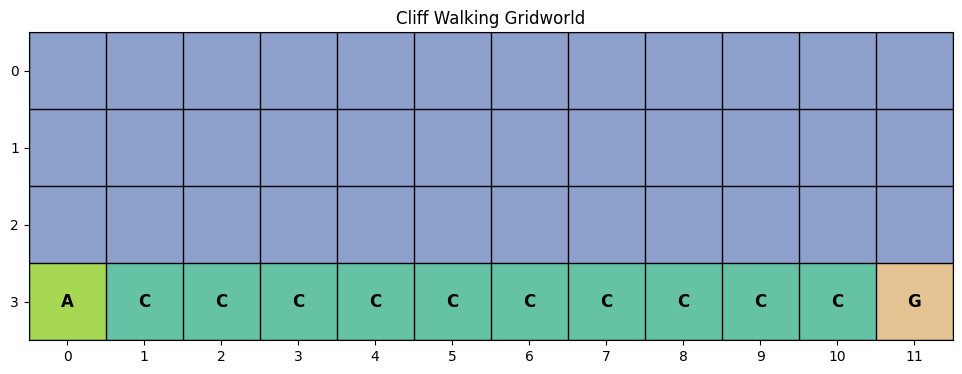

In [21]:
env = CliffWalkingEnv()
env.render_grid()
plt.show()

### Interpretação da visualização do ambiente

A figura confirma a estrutura esperada do Cliff Walking: o agente começa à esquerda, o objetivo fica à direita e o precipício ocupa quase toda a base do grid. Essa configuração cria um trade-off clássico: a rota mais curta passa muito perto do precipício, enquanto rotas mais altas são mais seguras, porém exigem mais passos.

## Q-Learning Tabular

O primeiro agente implementado é o Q-Learning tabular. Essa abordagem mantém uma tabela `Q(s,a)` com um valor para cada par estado-ação. Como o ambiente é pequeno e discreto, a tabela consegue representar separadamente todos os estados do grid.

A atualização é off-policy, usando o melhor valor estimado para o próximo estado:

`Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a Q(s',a) - Q(s,a)]`

Esse agente funciona como baseline para comparar a aproximação de função linear.

## Configuração do Q-Learning Tabular

A configuração define taxa de aprendizado, fator de desconto, agenda de exploração e limites de treinamento. O `epsilon` começa alto para incentivar exploração e decai até um valor mínimo, permitindo que o agente explore bastante no início e aja de forma mais gulosa ao final.

O histórico de treinamento guarda recompensa por episódio, tamanho do episódio, número de quedas no precipício e valor de `epsilon`, que são as métricas usadas nas curvas de aprendizado.

In [22]:
@dataclass(frozen=True)
class QLearningConfig:
    alpha: float = 0.5
    gamma: float = 1.0
    epsilon_start: float = 1.0
    epsilon_min: float = 0.05
    epsilon_decay: float = 0.995
    episodes: int = 500
    max_steps_per_episode: int = 1000


@dataclass
class TrainingHistory:
    episode_rewards: list[float]
    episode_lengths: list[int]
    cliff_falls: list[int]
    epsilon_values: list[float]

    @classmethod
    def empty(cls) -> "TrainingHistory":
        return cls(
            episode_rewards=[],
            episode_lengths=[],
            cliff_falls=[],
            epsilon_values=[],
        )

## Agente Tabular

O agente tabular inicializa `q_table` com formato `(linhas, colunas, ações)`. A seleção de ação usa política ε-greedy: com probabilidade `epsilon`, escolhe uma ação aleatória; caso contrário, escolhe uma das ações de maior valor estimado, com desempate aleatório.

O método `update()` implementa diretamente a regra do Q-Learning. Quando `done=True`, o alvo TD é apenas a recompensa imediata, pois não há próximo estado útil após o terminal.

In [23]:
class TabularQLearningAgent:
    def __init__(
        self,
        env_config: CliffWalkingConfig,
        config: QLearningConfig,
        seed: int = RANDOM_SEED,
    ) -> None:
        self.env_config = env_config
        self.config = config
        self.rng = np.random.default_rng(seed)
        self.epsilon = config.epsilon_start
        self.q_table = np.zeros(
            (env_config.rows, env_config.cols, len(env_config.actions)),
            dtype=float,
        )

    def select_action(self, state: State, training: bool = True) -> Action:
        if training and self.rng.random() < self.epsilon:
            return Action(int(self.rng.choice(self.env_config.actions)))

        row, col = state
        q_values = self.q_table[row, col]
        max_value = np.max(q_values)
        best_actions = np.flatnonzero(np.isclose(q_values, max_value))
        return Action(int(self.rng.choice(best_actions)))

    def update(
        self,
        state: State,
        action: int | Action,
        reward: float,
        next_state: State,
        done: bool,
    ) -> float:
        action = Action(action)
        row, col = state
        next_row, next_col = next_state

        current_q = self.q_table[row, col, action]
        target = reward if done else reward + self.config.gamma * np.max(self.q_table[next_row, next_col])
        td_error = target - current_q
        self.q_table[row, col, action] += self.config.alpha * td_error
        return float(td_error)

    def decay_epsilon(self) -> None:
        self.epsilon = max(
            self.config.epsilon_min,
            self.epsilon * self.config.epsilon_decay,
        )

## Treinamento do Agente Tabular

O loop de treinamento executa vários episódios. Em cada episódio, o ambiente é reiniciado, o agente interage até chegar ao objetivo ou atingir o limite de passos, e as métricas são acumuladas. Quedas no precipício são contadas pelo campo `info["event"] == "cliff"`.

In [24]:
def train_tabular_q_learning(
    env: CliffWalkingEnv,
    agent: TabularQLearningAgent,
    config: QLearningConfig,
) -> TrainingHistory:
    history = TrainingHistory.empty()

    for _ in range(config.episodes):
        state = env.reset()
        total_reward = 0.0
        cliff_falls = 0
        steps_taken = 0

        history.epsilon_values.append(agent.epsilon)

        for step in range(config.max_steps_per_episode):
            action = agent.select_action(state, training=True)
            next_state, reward, done, info = env.step(action)

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            cliff_falls += int(info["event"] == "cliff")
            steps_taken = step + 1
            state = next_state

            if done:
                break

        history.episode_rewards.append(total_reward)
        history.episode_lengths.append(steps_taken)
        history.cliff_falls.append(cliff_falls)
        agent.decay_epsilon()

    return history

## Funções de Apoio para Gráficos

As funções abaixo suavizam e visualizam as métricas de treinamento. A média móvel ajuda a observar a tendência de aprendizado sem depender tanto da variação episódio a episódio.

In [25]:
def moving_average(values: list[float] | np.ndarray, window: int = 20) -> np.ndarray:
    values_array = np.asarray(values, dtype=float)
    if len(values_array) < window:
        return values_array

    kernel = np.ones(window) / window
    return np.convolve(values_array, kernel, mode="valid")


def plot_tabular_training_history(history: TrainingHistory, window: int = 20) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    episodes = np.arange(1, len(history.episode_rewards) + 1)
    reward_average = moving_average(history.episode_rewards, window=window)
    average_episodes = (
        episodes if len(history.episode_rewards) < window
        else np.arange(window, len(history.episode_rewards) + 1)
    )

    axes[0].plot(episodes, history.episode_rewards, alpha=0.35, label="Recompensa por episódio")
    if len(reward_average) > 0:
        axes[0].plot(average_episodes, reward_average, label=f"Média móvel ({window})")
    axes[0].set_ylabel("Recompensa")
    axes[0].legend()

    axes[1].plot(episodes, history.episode_lengths, color="tab:orange")
    axes[1].set_ylabel("Passos")

    axes[2].plot(episodes, history.cliff_falls, color="tab:red")
    axes[2].set_ylabel("Cliff falls")
    axes[2].set_xlabel("Episódio")

    fig.suptitle("Métricas de Treinamento - Q-Learning Tabular")
    fig.tight_layout()
    return fig, axes

## Visualização da Política Tabular

A política gulosa do agente tabular é obtida por `argmax_a Q(s,a)`. As setas mostram qual ação o agente escolheria em cada estado não terminal e fora do precipício. Essa visualização permite verificar se o agente aprendeu uma rota coerente até o objetivo.

In [26]:
def greedy_policy_from_q_table(agent: TabularQLearningAgent) -> dict[State, Action]:
    policy: dict[State, Action] = {}

    for row in range(agent.env_config.rows):
        for col in range(agent.env_config.cols):
            state = (row, col)
            if state in agent.env_config.cliff_cells or state == agent.env_config.goal_state:
                continue
            policy[state] = Action(int(np.argmax(agent.q_table[row, col])))

    return policy


def render_tabular_policy(env: CliffWalkingEnv, agent: TabularQLearningAgent) -> plt.Axes:
    ax = env.render_grid()
    policy = greedy_policy_from_q_table(agent)

    for (row, col), action in policy.items():
        if (row, col) == env.config.start_state:
            text_y = row + 0.2
        else:
            text_y = row
        ax.text(
            col,
            text_y,
            ACTION_SYMBOLS[action],
            ha="center",
            va="center",
            fontsize=14,
            color="black",
        )

    start_row, start_col = env.config.start_state
    goal_row, goal_col = env.config.goal_state
    ax.text(start_col, start_row, "S", ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(goal_col, goal_row, "G", ha="center", va="center", fontsize=12, fontweight="bold")
    for cliff_row, cliff_col in env.config.cliff_cells:
        ax.text(cliff_col, cliff_row, "C", ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_title("Política Gulosa Aprendida pelo Q-Learning Tabular")
    return ax

## Verificações do Q-Learning Tabular

As verificações abaixo garantem que a tabela possui o formato esperado, que a política retorna ações válidas, que a atualização TD altera o valor correto e que um treinamento curto produz métricas consistentes.

In [27]:
q_config = QLearningConfig()
q_env = CliffWalkingEnv()
q_agent = TabularQLearningAgent(q_env.config, q_config)

assert q_agent.q_table.shape == (ROWS, COLS, len(Action))
assert isinstance(q_agent.select_action(START_STATE), Action)

update_config = QLearningConfig(alpha=0.5, gamma=1.0, epsilon_start=0.0)
update_agent = TabularQLearningAgent(q_env.config, update_config)
update_agent.update((0, 0), Action.RIGHT, -1, (0, 1), done=False)
assert np.isclose(update_agent.q_table[0, 0, Action.RIGHT], -0.5)

smoke_config = QLearningConfig(episodes=5, max_steps_per_episode=100)
smoke_env = CliffWalkingEnv()
smoke_agent = TabularQLearningAgent(smoke_env.config, smoke_config)
smoke_history = train_tabular_q_learning(smoke_env, smoke_agent, smoke_config)

assert len(smoke_history.episode_rewards) == 5
assert len(smoke_history.episode_lengths) == 5
assert len(smoke_history.cliff_falls) == 5
assert len(smoke_history.epsilon_values) == 5

print("Verificações do Q-Learning tabular aprovadas.")

Verificações do Q-Learning tabular aprovadas.


## Treinamento Completo do Agente Tabular

Aqui o agente tabular é treinado com os hiperparâmetros definidos. A comparação entre a média das primeiras 20 recompensas e a média das últimas 20 recompensas verifica se houve melhora durante o treinamento.

In [28]:
tabular_config = QLearningConfig()
tabular_env = CliffWalkingEnv()
tabular_agent = TabularQLearningAgent(tabular_env.config, tabular_config)
tabular_history = train_tabular_q_learning(tabular_env, tabular_agent, tabular_config)

initial_average_reward = float(np.mean(tabular_history.episode_rewards[:20]))
final_average_reward = float(np.mean(tabular_history.episode_rewards[-20:]))

print(f"Recompensa média inicial (primeiros 20): {initial_average_reward:.2f}")
print(f"Recompensa média final (últimos 20): {final_average_reward:.2f}")

assert final_average_reward > initial_average_reward

Recompensa média inicial (primeiros 20): -9460.50
Recompensa média final (últimos 20): -72.80


### Interpretação do treinamento tabular

A célula imprime a média de recompensa no início e no final do treinamento. Como as recompensas são negativas, uma média final menos negativa indica melhora: o agente passa a cair menos no precipício e a alcançar o objetivo com trajetórias mais curtas.

## Rollout Guloso do Agente Tabular

Depois do treinamento, o agente é avaliado sem exploração (`training=False`). Esse rollout mostra a política final aprendida: se ela alcança o objetivo, em quantos passos e com qual retorno acumulado.

In [29]:
def run_greedy_rollout(
    env: CliffWalkingEnv,
    agent: TabularQLearningAgent,
    max_steps: int,
) -> tuple[list[State], float, bool]:
    state = env.reset()
    states = [state]
    total_reward = 0.0

    for _ in range(max_steps):
        action = agent.select_action(state, training=False)
        state, reward, done, _ = env.step(action)
        states.append(state)
        total_reward += reward

        if done:
            return states, total_reward, True

    return states, total_reward, False


greedy_env = CliffWalkingEnv()
greedy_states, greedy_reward, reached_goal = run_greedy_rollout(
    greedy_env,
    tabular_agent,
    tabular_config.max_steps_per_episode,
)

print(f"Recompensa do rollout guloso: {greedy_reward:.2f}")
print(f"Passos do rollout guloso: {len(greedy_states) - 1}")
print(f"Alcançou o objetivo: {reached_goal}")

assert reached_goal is True

Recompensa do rollout guloso: -13.00
Passos do rollout guloso: 13
Alcançou o objetivo: True


### Interpretação do rollout tabular

O rollout guloso avalia a política final sem exploração. Quando o agente alcança o objetivo em poucos passos, isso indica que a tabela `Q(s,a)` aprendeu valores suficientemente precisos para guiar o agente pelo grid.

## Métricas e Política do Agente Tabular

Os gráficos abaixo mostram a evolução da recompensa, do número de passos e das quedas no precipício. A política final permite inspecionar visualmente a rota aprendida pelo agente tabular.

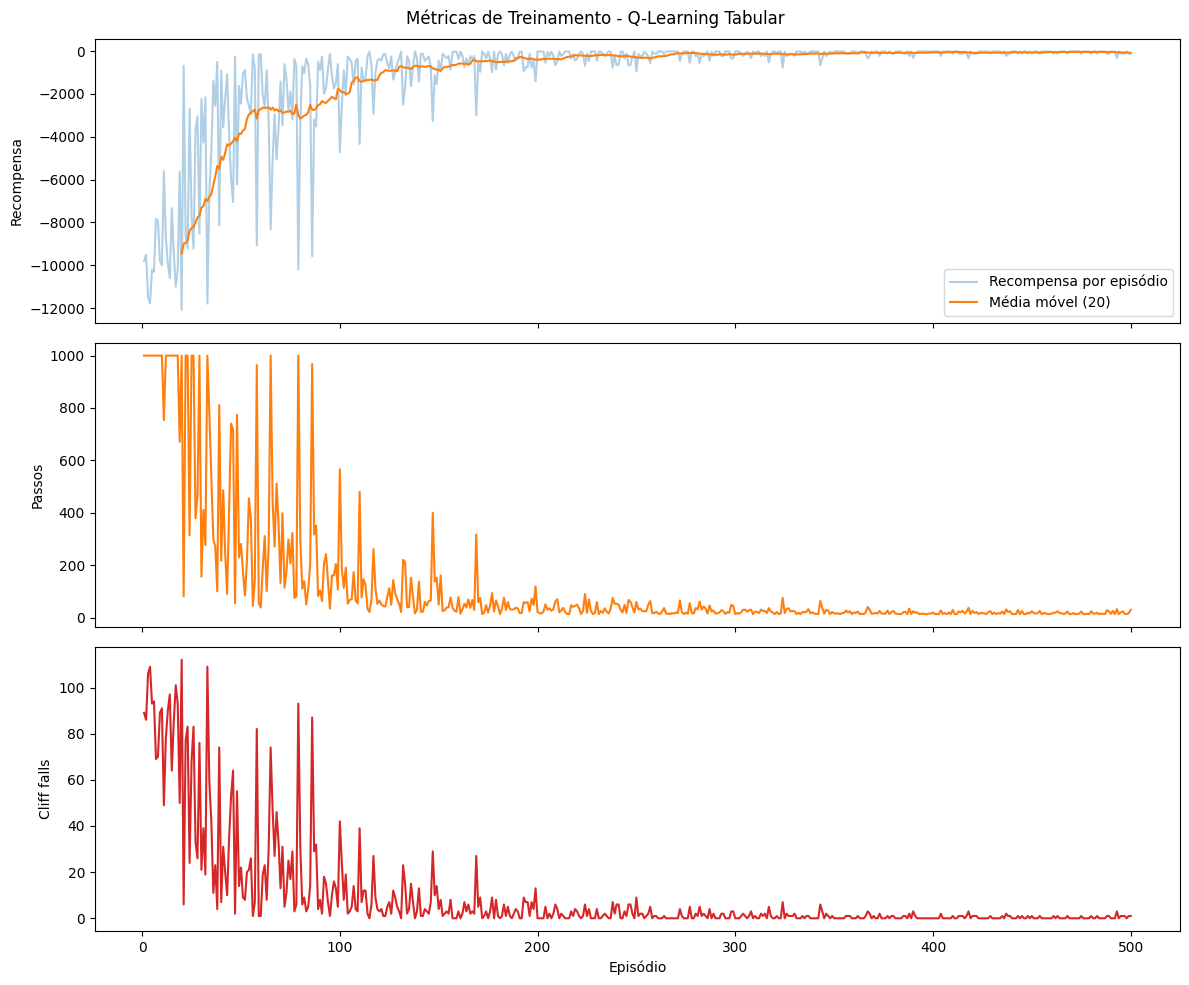

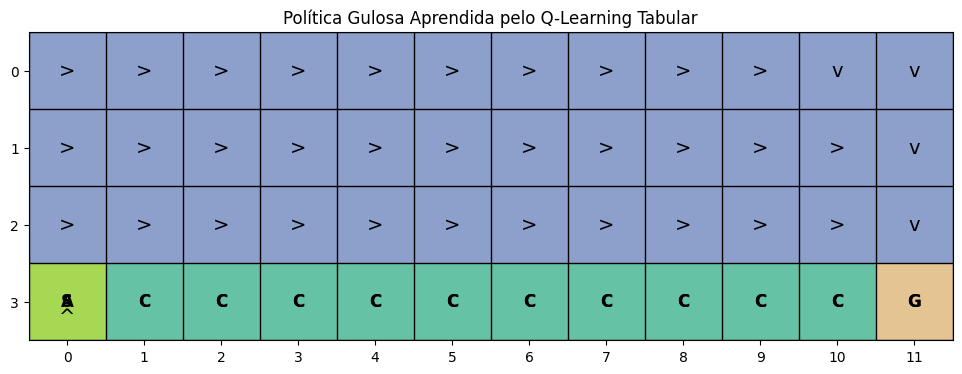

In [30]:
plot_tabular_training_history(tabular_history)
plt.show()

render_tabular_policy(CliffWalkingEnv(), tabular_agent)
plt.show()

### Leitura dos gráficos tabulares

A curva de recompensa mostra a evolução do retorno acumulado por episódio. A curva de passos indica se o agente está encontrando trajetórias mais curtas. A contagem de quedas no precipício mostra se a política está aprendendo a evitar a região de alto custo.

## Q-Learning com Aproximação Linear e Semi-Gradiente

O segundo agente substitui a tabela `Q(s,a)` por uma função linear parametrizada:

`Q(s,a,w) = w^T phi(s,a)`

Nesse caso, o valor de uma ação não é armazenado diretamente em uma célula da tabela. Ele é calculado a partir de um vetor de características `phi(s,a)` e de um vetor de pesos `w`. Essa mudança permite generalização entre estados parecidos, mas também introduz riscos de instabilidade e generalização inadequada.

## Configuração e Vetor de Features

O vetor base de características do estado contém cinco componentes: viés, linha normalizada, coluna normalizada, distância Manhattan normalizada até o objetivo e indicador de proximidade com o precipício.

Para representar `phi(s,a)`, usamos blocos por ação. O vetor final tem tamanho `len(Action) * 5 = 20`: apenas o bloco da ação escolhida recebe as features do estado; os outros blocos ficam zerados. Assim, cada ação aprende seus próprios pesos, mas compartilha a mesma estrutura de representação.

O parâmetro `weight_clip_value = 100.0` limita os pesos para evitar divergência numérica. Isso é importante porque Q-Learning com aproximação linear é off-policy e pode se tornar instável, especialmente com `gamma = 1.0`.

In [31]:
@dataclass(frozen=True)
class LinearQLearningConfig:
    alpha: float = 0.05
    gamma: float = 1.0
    epsilon_start: float = 1.0
    epsilon_min: float = 0.05
    epsilon_decay: float = 0.995
    episodes: int = 500
    max_steps_per_episode: int = 1000
    weight_clip_value: float = 100.0


BASE_FEATURE_COUNT = 5
LINEAR_FEATURE_COUNT = len(Action) * BASE_FEATURE_COUNT


def state_features(state: State, env_config: CliffWalkingConfig) -> np.ndarray:
    row, col = state
    goal_row, goal_col = env_config.goal_state

    row_norm = row / (env_config.rows - 1)
    col_norm = col / (env_config.cols - 1)
    max_goal_distance = (env_config.rows - 1) + (env_config.cols - 1)
    goal_distance_norm = (abs(row - goal_row) + abs(col - goal_col)) / max_goal_distance

    neighbor_states = {state}
    for action in env_config.actions:
        row_delta, col_delta = ACTION_DELTAS[action]
        neighbor_row = min(max(row + row_delta, 0), env_config.rows - 1)
        neighbor_col = min(max(col + col_delta, 0), env_config.cols - 1)
        neighbor_states.add((neighbor_row, neighbor_col))
    cliff_proximity = float(any(neighbor in env_config.cliff_cells for neighbor in neighbor_states))

    return np.array(
        [1.0, row_norm, col_norm, goal_distance_norm, cliff_proximity],
        dtype=float,
    )


def feature_vector(state: State, action: int | Action, env_config: CliffWalkingConfig) -> np.ndarray:
    action = Action(action)
    features = np.zeros(LINEAR_FEATURE_COUNT, dtype=float)
    start = int(action) * BASE_FEATURE_COUNT
    end = start + BASE_FEATURE_COUNT
    features[start:end] = state_features(state, env_config)
    return features

## Agente Linear com Semi-Gradiente

O agente linear calcula `Q(s,a,w)` pelo produto interno entre pesos e features. A política também é ε-greedy, com desempate aleatório entre ações de mesmo valor.

A atualização implementa a regra de semi-gradiente:

`w <- w + alpha * [r + gamma * max_a Q(s',a,w) - Q(s,a,w)] * phi(s,a)`

Como `Q` é linear em `w`, o gradiente de `Q(s,a,w)` em relação a `w` é o próprio `phi(s,a)`.

In [32]:
class LinearSemiGradientQLearningAgent:
    def __init__(
        self,
        env_config: CliffWalkingConfig,
        config: LinearQLearningConfig,
        seed: int = RANDOM_SEED,
    ) -> None:
        self.env_config = env_config
        self.config = config
        self.rng = np.random.default_rng(seed)
        self.epsilon = config.epsilon_start
        self.weights = np.zeros(LINEAR_FEATURE_COUNT, dtype=float)

    def q_value(self, state: State, action: int | Action) -> float:
        features = feature_vector(state, action, self.env_config)
        return float(np.dot(self.weights, features))

    def q_values(self, state: State) -> np.ndarray:
        return np.array([self.q_value(state, action) for action in self.env_config.actions], dtype=float)

    def select_action(self, state: State, training: bool = True) -> Action:
        if training and self.rng.random() < self.epsilon:
            return Action(int(self.rng.choice(self.env_config.actions)))

        q_values = self.q_values(state)
        max_value = np.max(q_values)
        best_actions = np.flatnonzero(np.isclose(q_values, max_value))
        return Action(int(self.rng.choice(best_actions)))

    def update(
        self,
        state: State,
        action: int | Action,
        reward: float,
        next_state: State,
        done: bool,
    ) -> float:
        action = Action(action)
        features = feature_vector(state, action, self.env_config)
        current_q = self.q_value(state, action)
        target = reward if done else reward + self.config.gamma * np.max(self.q_values(next_state))
        td_error = target - current_q
        self.weights += self.config.alpha * td_error * features
        np.clip(
            self.weights,
            -self.config.weight_clip_value,
            self.config.weight_clip_value,
            out=self.weights,
        )
        return float(td_error)

    def decay_epsilon(self) -> None:
        self.epsilon = max(
            self.config.epsilon_min,
            self.epsilon * self.config.epsilon_decay,
        )

## Treinamento do Agente Linear

O loop de treinamento do agente linear segue a mesma estrutura do tabular para manter a comparação justa: mesmos campos de histórico, mesma estratégia de exploração e mesmas métricas. A diferença está apenas na forma como os valores de ação são representados e atualizados.

In [33]:
def train_linear_q_learning(
    env: CliffWalkingEnv,
    agent: LinearSemiGradientQLearningAgent,
    config: LinearQLearningConfig,
) -> TrainingHistory:
    history = TrainingHistory.empty()

    for _ in range(config.episodes):
        state = env.reset()
        total_reward = 0.0
        cliff_falls = 0
        steps_taken = 0

        history.epsilon_values.append(agent.epsilon)

        for step in range(config.max_steps_per_episode):
            action = agent.select_action(state, training=True)
            next_state, reward, done, info = env.step(action)

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            cliff_falls += int(info["event"] == "cliff")
            steps_taken = step + 1
            state = next_state

            if done:
                break

        history.episode_rewards.append(total_reward)
        history.episode_lengths.append(steps_taken)
        history.cliff_falls.append(cliff_falls)
        agent.decay_epsilon()

    return history

## Gráficos do Agente Linear

As métricas do agente linear são visualizadas com o mesmo padrão usado no agente tabular. Isso facilita comparar aprendizado, estabilidade, número de passos e frequência de quedas no precipício.

In [34]:
def plot_linear_training_history(history: TrainingHistory, window: int = 20) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    episodes = np.arange(1, len(history.episode_rewards) + 1)
    reward_average = moving_average(history.episode_rewards, window=window)
    average_episodes = (
        episodes if len(history.episode_rewards) < window
        else np.arange(window, len(history.episode_rewards) + 1)
    )

    axes[0].plot(episodes, history.episode_rewards, alpha=0.35, label="Recompensa por episódio")
    if len(reward_average) > 0:
        axes[0].plot(average_episodes, reward_average, label=f"Média móvel ({window})")
    axes[0].set_ylabel("Recompensa")
    axes[0].legend()

    axes[1].plot(episodes, history.episode_lengths, color="tab:orange")
    axes[1].set_ylabel("Passos")

    axes[2].plot(episodes, history.cliff_falls, color="tab:red")
    axes[2].set_ylabel("Cliff falls")
    axes[2].set_xlabel("Episódio")

    fig.suptitle("Métricas de Treinamento - Q-Learning Linear com Semi-Gradiente")
    fig.tight_layout()
    return fig, axes

## Política e Função de Valor do Agente Linear

A política gulosa do agente linear é obtida por `argmax_a Q(s,a,w)`. A função de valor estimada é calculada por `V(s) = max_a Q(s,a,w)`. O heatmap de `V(s)` ajuda a observar como a aproximação linear distribui valores pelo grid, inclusive em regiões próximas ao precipício.

In [35]:
def greedy_policy_from_linear_agent(agent: LinearSemiGradientQLearningAgent) -> dict[State, Action]:
    policy: dict[State, Action] = {}

    for row in range(agent.env_config.rows):
        for col in range(agent.env_config.cols):
            state = (row, col)
            if state in agent.env_config.cliff_cells or state == agent.env_config.goal_state:
                continue
            policy[state] = Action(int(np.argmax(agent.q_values(state))))

    return policy


def render_linear_policy(env: CliffWalkingEnv, agent: LinearSemiGradientQLearningAgent) -> plt.Axes:
    ax = env.render_grid()
    policy = greedy_policy_from_linear_agent(agent)

    for (row, col), action in policy.items():
        text_y = row + 0.2 if (row, col) == env.config.start_state else row
        ax.text(
            col,
            text_y,
            ACTION_SYMBOLS[action],
            ha="center",
            va="center",
            fontsize=14,
            color="black",
        )

    start_row, start_col = env.config.start_state
    goal_row, goal_col = env.config.goal_state
    ax.text(start_col, start_row, "S", ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(goal_col, goal_row, "G", ha="center", va="center", fontsize=12, fontweight="bold")
    for cliff_row, cliff_col in env.config.cliff_cells:
        ax.text(cliff_col, cliff_row, "C", ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_title("Política Gulosa Aprendida pelo Agente Linear com Semi-Gradiente")
    return ax


def estimated_value_grid(agent: LinearSemiGradientQLearningAgent) -> np.ndarray:
    values = np.full((agent.env_config.rows, agent.env_config.cols), np.nan, dtype=float)

    for row in range(agent.env_config.rows):
        for col in range(agent.env_config.cols):
            state = (row, col)
            if state in agent.env_config.cliff_cells:
                continue
            if state == agent.env_config.goal_state:
                values[row, col] = 0.0
            else:
                values[row, col] = float(np.max(agent.q_values(state)))

    return values


def render_value_heatmap(agent: LinearSemiGradientQLearningAgent) -> plt.Axes:
    values = estimated_value_grid(agent)
    _, ax = plt.subplots(figsize=(12, 4))
    image = ax.imshow(values, cmap="viridis")
    plt.colorbar(image, ax=ax, label="V(s) estimado")

    ax.set_xticks(np.arange(agent.env_config.cols))
    ax.set_yticks(np.arange(agent.env_config.rows))
    ax.set_xticks(np.arange(-0.5, agent.env_config.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, agent.env_config.rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_title("Função de Valor Estimada pelo Agente Linear")

    for row in range(agent.env_config.rows):
        for col in range(agent.env_config.cols):
            state = (row, col)
            if state in agent.env_config.cliff_cells:
                label = "C"
            elif state == agent.env_config.start_state:
                label = "S"
            elif state == agent.env_config.goal_state:
                label = "G"
            else:
                label = f"{values[row, col]:.1f}"
            ax.text(col, row, label, ha="center", va="center", color="white", fontsize=10)

    return ax

## Verificações do Agente Linear

As verificações confirmam que o vetor de features possui tamanho correto, que apenas o bloco da ação escolhida é preenchido, que `q_values()` retorna um valor por ação e que uma atualização simples altera os pesos conforme a regra semi-gradiente.

In [36]:
linear_config = LinearQLearningConfig()
linear_env = CliffWalkingEnv()
linear_agent = LinearSemiGradientQLearningAgent(linear_env.config, linear_config)

start_features = state_features(START_STATE, linear_env.config)
up_features = feature_vector(START_STATE, Action.UP, linear_env.config)
right_features = feature_vector(START_STATE, Action.RIGHT, linear_env.config)

assert up_features.shape == (LINEAR_FEATURE_COUNT,)
assert LINEAR_FEATURE_COUNT == 20
assert np.count_nonzero(up_features[:BASE_FEATURE_COUNT]) == np.count_nonzero(start_features)
assert np.count_nonzero(up_features[BASE_FEATURE_COUNT:]) == 0
assert np.count_nonzero(right_features[:BASE_FEATURE_COUNT]) == 0
assert np.count_nonzero(right_features[BASE_FEATURE_COUNT:2 * BASE_FEATURE_COUNT]) == np.count_nonzero(start_features)
assert linear_agent.q_values(START_STATE).shape == (len(Action),)

update_config = LinearQLearningConfig(alpha=0.05, gamma=1.0, epsilon_start=0.0)
update_agent = LinearSemiGradientQLearningAgent(linear_env.config, update_config)
td_error = update_agent.update(START_STATE, Action.RIGHT, -1, (2, 0), done=False)
expected_weights = np.zeros(LINEAR_FEATURE_COUNT)
expected_weights[BASE_FEATURE_COUNT:2 * BASE_FEATURE_COUNT] = -0.05 * start_features

assert np.isclose(td_error, -1.0)
assert np.allclose(update_agent.weights, expected_weights)

smoke_config = LinearQLearningConfig(episodes=5, max_steps_per_episode=100)
smoke_env = CliffWalkingEnv()
smoke_agent = LinearSemiGradientQLearningAgent(smoke_env.config, smoke_config)
smoke_history = train_linear_q_learning(smoke_env, smoke_agent, smoke_config)

assert len(smoke_history.episode_rewards) == 5
assert len(smoke_history.episode_lengths) == 5
assert len(smoke_history.cliff_falls) == 5
assert len(smoke_history.epsilon_values) == 5

print("Verificações do Q-Learning linear com semi-gradiente aprovadas.")

Verificações do Q-Learning linear com semi-gradiente aprovadas.


## Treinamento Completo do Agente Linear

O agente linear é treinado com a mesma quantidade de episódios do tabular. A melhora entre as primeiras e últimas recompensas médias indica que a função aproximadora aprendeu uma política útil, mesmo sem armazenar uma tabela completa de valores.

In [37]:
linear_config = LinearQLearningConfig()
linear_env = CliffWalkingEnv()
linear_agent = LinearSemiGradientQLearningAgent(linear_env.config, linear_config)
linear_history = train_linear_q_learning(linear_env, linear_agent, linear_config)

linear_initial_average_reward = float(np.mean(linear_history.episode_rewards[:20]))
linear_final_average_reward = float(np.mean(linear_history.episode_rewards[-20:]))

print(f"Recompensa média inicial (primeiros 20): {linear_initial_average_reward:.2f}")
print(f"Recompensa média final (últimos 20): {linear_final_average_reward:.2f}")

assert linear_final_average_reward > linear_initial_average_reward

Recompensa média inicial (primeiros 20): -10602.15
Recompensa média final (últimos 20): -21.25


### Interpretação do treinamento linear

A aproximação linear também melhora ao longo do treinamento, mas seu comportamento é diferente do tabular. Como os pesos são compartilhados por features, uma atualização em um estado pode afetar estimativas em outros estados semelhantes. Isso permite generalização, mas pode tornar o aprendizado menos local e menos estável.

## Rollout Guloso do Agente Linear

A avaliação sem exploração mede a política final aprendida pela aproximação linear. Esse resultado é importante porque uma curva de aprendizado melhor não garante necessariamente uma política gulosa mais curta ou mais segura.

In [38]:
linear_greedy_env = CliffWalkingEnv()
linear_greedy_states, linear_greedy_reward, linear_reached_goal = run_greedy_rollout(
    linear_greedy_env,
    linear_agent,
    linear_config.max_steps_per_episode,
)

print(f"Recompensa do rollout guloso linear: {linear_greedy_reward:.2f}")
print(f"Passos do rollout guloso linear: {len(linear_greedy_states) - 1}")
print(f"Alcançou o objetivo: {linear_reached_goal}")

assert linear_reached_goal is True

Recompensa do rollout guloso linear: -17.00
Passos do rollout guloso linear: 17
Alcançou o objetivo: True


### Interpretação do rollout linear

O rollout guloso verifica se a função aproximadora aprendeu uma política executável. Mesmo quando alcança o objetivo, o caminho pode ser mais longo que o tabular, pois a representação linear não memoriza cada par estado-ação de forma independente.

## Métricas, Política e Valor do Agente Linear

Os gráficos abaixo mostram o comportamento do agente linear ao longo do treinamento, a política gulosa final e a função de valor estimada. Essas visualizações serão usadas na comparação final com o agente tabular.

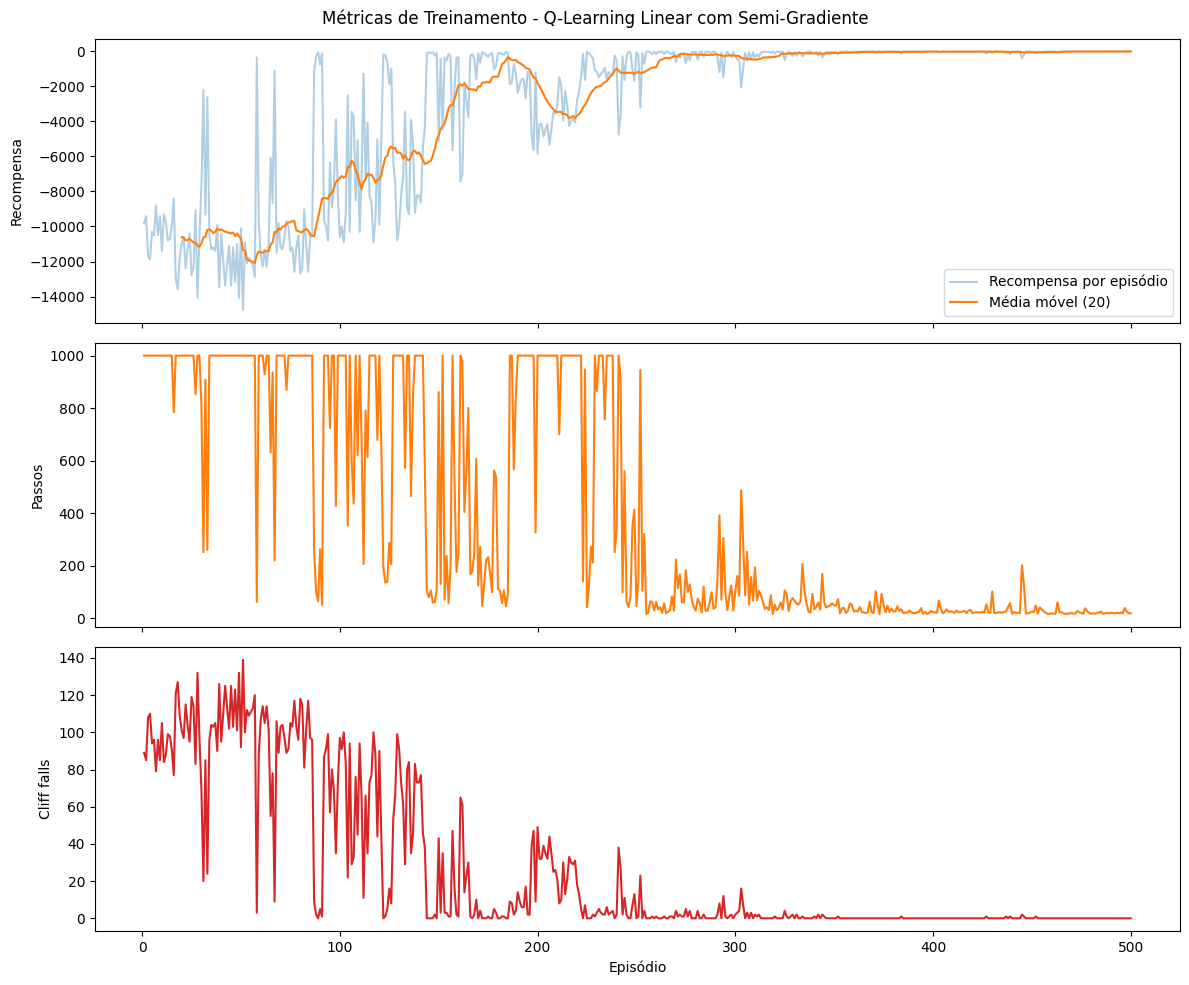

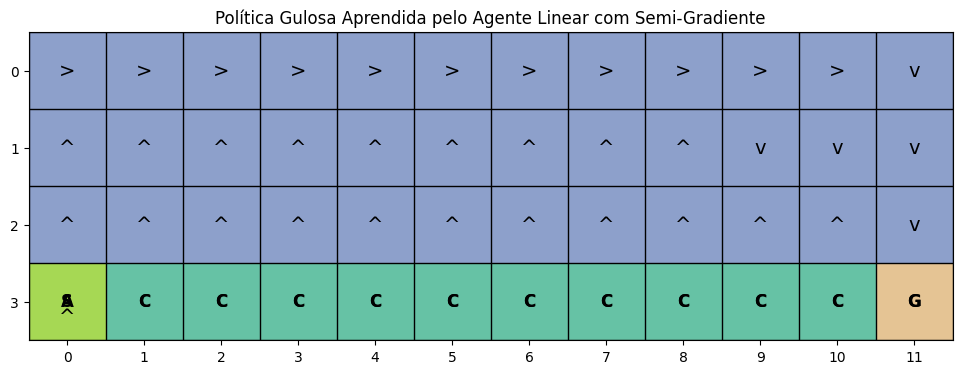

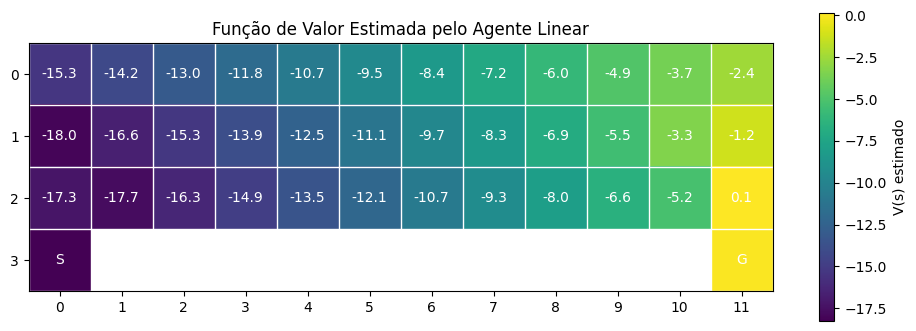

In [39]:
plot_linear_training_history(linear_history)
plt.show()

render_linear_policy(CliffWalkingEnv(), linear_agent)
plt.show()

render_value_heatmap(linear_agent)
plt.show()

### Leitura dos gráficos lineares

A política e o heatmap do agente linear mostram o efeito da generalização. Estados com features parecidas podem receber valores semelhantes, o que ajuda em regiões regulares do grid, mas pode prejudicar perto do precipício, onde pequenas diferenças de posição mudam muito o risco da ação.

## Comparação entre Q-Learning Tabular e Aproximação Linear

A comparação final avalia os dois agentes em termos de curva de aprendizado, política aprendida, função de valor estimada, retorno do rollout guloso e exposição ao precipício. Essa é a parte analítica central da atividade, pois mostra o que muda ao substituir uma tabela de valores por uma função parametrizada.

## Funções de Apoio para Comparação

As funções abaixo calculam a função de valor do agente tabular, renderizam heatmaps no mesmo formato e consolidam métricas em uma tabela simples. O objetivo é comparar os agentes sem retreiná-los, usando os objetos já produzidos nas seções anteriores.

In [40]:
def tabular_value_grid(agent: TabularQLearningAgent) -> np.ndarray:
    values = np.full((agent.env_config.rows, agent.env_config.cols), np.nan, dtype=float)

    for row in range(agent.env_config.rows):
        for col in range(agent.env_config.cols):
            state = (row, col)
            if state in agent.env_config.cliff_cells:
                continue
            if state == agent.env_config.goal_state:
                values[row, col] = 0.0
            else:
                values[row, col] = float(np.max(agent.q_table[row, col]))

    return values


def render_value_heatmap_on_axis(
    values: np.ndarray,
    env_config: CliffWalkingConfig,
    title: str,
    ax: plt.Axes,
) -> plt.Axes:
    image = ax.imshow(values, cmap="viridis")
    ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="V(s) estimado")

    ax.set_xticks(np.arange(env_config.cols))
    ax.set_yticks(np.arange(env_config.rows))
    ax.set_xticks(np.arange(-0.5, env_config.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env_config.rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_title(title)

    for row in range(env_config.rows):
        for col in range(env_config.cols):
            state = (row, col)
            if state in env_config.cliff_cells:
                label = "C"
            elif state == env_config.start_state:
                label = "S"
            elif state == env_config.goal_state:
                label = "G"
            else:
                label = f"{values[row, col]:.1f}"
            ax.text(col, row, label, ha="center", va="center", color="white", fontsize=9)

    return ax


def render_tabular_value_heatmap(agent: TabularQLearningAgent) -> plt.Axes:
    _, ax = plt.subplots(figsize=(12, 4))
    return render_value_heatmap_on_axis(
        tabular_value_grid(agent),
        agent.env_config,
        "Função de Valor Estimada pelo Agente Tabular",
        ax,
    )


def summarize_agent_performance(
    name: str,
    history: TrainingHistory,
    rollout_reward: float,
    rollout_states: list[State],
    reached_goal: bool,
    window: int = 20,
) -> dict[str, float | int | bool | str]:
    return {
        "agente": name,
        "recompensa_media_inicial": float(np.mean(history.episode_rewards[:window])),
        "recompensa_media_final": float(np.mean(history.episode_rewards[-window:])),
        "recompensa_rollout_guloso": float(rollout_reward),
        "passos_rollout_guloso": len(rollout_states) - 1,
        "alcancou_objetivo": bool(reached_goal),
        "total_quedas_precipicio": int(np.sum(history.cliff_falls)),
    }

## Curva de Aprendizado Comparada

A curva combinada usa média móvel de recompensa para comparar a tendência de aprendizado dos dois agentes. Valores menos negativos indicam melhor desempenho, pois cada passo e cada queda no precipício geram penalidades.

In [41]:
def plot_combined_learning_curve(
    tabular_history: TrainingHistory,
    linear_history: TrainingHistory,
    window: int = 20,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(12, 5))

    tabular_average = moving_average(tabular_history.episode_rewards, window=window)
    linear_average = moving_average(linear_history.episode_rewards, window=window)
    episodes = np.arange(window, len(tabular_history.episode_rewards) + 1)

    ax.plot(episodes, tabular_average, label="Tabular Q-Learning")
    ax.plot(episodes, linear_average, label="Linear Semi-Gradient Q-Learning")
    ax.set_title(f"Média Móvel da Recompensa ({window} episódios)")
    ax.set_xlabel("Episódio")
    ax.set_ylabel("Recompensa média")
    ax.legend()
    ax.grid(alpha=0.3)

    return fig, ax

## Comparação das Políticas Aprendidas

As políticas são mostradas lado a lado. O agente tabular tende a memorizar uma rota eficiente para o grid específico, enquanto o agente linear escolhe ações a partir de uma representação compartilhada por features.

In [42]:
def render_policy_on_axis(
    env: CliffWalkingEnv,
    policy: dict[State, Action],
    title: str,
    ax: plt.Axes,
) -> plt.Axes:
    env.render_grid(ax=ax)

    for (row, col), action in policy.items():
        text_y = row + 0.2 if (row, col) == env.config.start_state else row
        ax.text(
            col,
            text_y,
            ACTION_SYMBOLS[action],
            ha="center",
            va="center",
            fontsize=14,
            color="black",
        )

    start_row, start_col = env.config.start_state
    goal_row, goal_col = env.config.goal_state
    ax.text(start_col, start_row, "S", ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(goal_col, goal_row, "G", ha="center", va="center", fontsize=12, fontweight="bold")
    for cliff_row, cliff_col in env.config.cliff_cells:
        ax.text(cliff_col, cliff_row, "C", ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_title(title)
    return ax


def plot_policy_comparison(
    tabular_agent: TabularQLearningAgent,
    linear_agent: LinearSemiGradientQLearningAgent,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    render_policy_on_axis(
        CliffWalkingEnv(),
        greedy_policy_from_q_table(tabular_agent),
        "Política do Q-Learning Tabular",
        axes[0],
    )
    render_policy_on_axis(
        CliffWalkingEnv(),
        greedy_policy_from_linear_agent(linear_agent),
        "Política do Agente Linear com Semi-Gradiente",
        axes[1],
    )

    fig.tight_layout()
    return fig, axes

## Comparação das Funções de Valor

Os heatmaps mostram `V(s) = max_a Q(s,a)` para o agente tabular e `V(s) = max_a Q(s,a,w)` para o agente linear. A comparação evidencia como a tabela aprende valores locais específicos, enquanto a aproximação linear suaviza e generaliza valores entre estados.

In [43]:
def plot_value_heatmap_comparison(
    tabular_agent: TabularQLearningAgent,
    linear_agent: LinearSemiGradientQLearningAgent,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    render_value_heatmap_on_axis(
        tabular_value_grid(tabular_agent),
        tabular_agent.env_config,
        "V(s) Estimado - Tabular",
        axes[0],
    )
    render_value_heatmap_on_axis(
        estimated_value_grid(linear_agent),
        linear_agent.env_config,
        "V(s) Estimado - Linear",
        axes[1],
    )

    fig.tight_layout()
    return fig, axes

## Tabela Comparativa e Verificações Finais

A tabela resume os indicadores principais: recompensa média inicial, recompensa média final, retorno do rollout guloso, tamanho da trajetória gulosa, chegada ao objetivo e total de quedas no precipício durante o treinamento.

Também são criadas variáveis de conclusão para identificar qual agente teve melhor recompensa final média, qual encontrou o caminho guloso mais curto e qual caiu menos vezes no precipício.

In [44]:
comparison_table = [
    summarize_agent_performance(
        "Tabular Q-Learning",
        tabular_history,
        greedy_reward,
        greedy_states,
        reached_goal,
    ),
    summarize_agent_performance(
        "Linear Semi-Gradient Q-Learning",
        linear_history,
        linear_greedy_reward,
        linear_greedy_states,
        linear_reached_goal,
    ),
]

tabular_summary, linear_summary = comparison_table

better_final_reward_agent = max(comparison_table, key=lambda row: row["recompensa_media_final"])["agente"]
shorter_greedy_path_agent = min(comparison_table, key=lambda row: row["passos_rollout_guloso"])["agente"]
fewer_cliff_falls_agent = min(comparison_table, key=lambda row: row["total_quedas_precipicio"])["agente"]

assert len(tabular_history.episode_rewards) == len(linear_history.episode_rewards)
assert reached_goal is True
assert linear_reached_goal is True
assert [row["agente"] for row in comparison_table] == [
    "Tabular Q-Learning",
    "Linear Semi-Gradient Q-Learning",
]
assert tabular_value_grid(tabular_agent).shape == (ROWS, COLS)
assert estimated_value_grid(linear_agent).shape == (ROWS, COLS)

for row in comparison_table:
    print(row)

print(f"Melhor recompensa média final: {better_final_reward_agent}")
print(f"Menor caminho guloso: {shorter_greedy_path_agent}")
print(f"Menos quedas no precipício durante o treino: {fewer_cliff_falls_agent}")
print("Verificações da comparação aprovadas.")

{'agente': 'Tabular Q-Learning', 'recompensa_media_inicial': -9460.5, 'recompensa_media_final': -72.8, 'recompensa_rollout_guloso': -13.0, 'passos_rollout_guloso': 13, 'alcancou_objetivo': True, 'total_quedas_precipicio': 4847}
{'agente': 'Linear Semi-Gradient Q-Learning', 'recompensa_media_inicial': -10602.15, 'recompensa_media_final': -21.25, 'recompensa_rollout_guloso': -17.0, 'passos_rollout_guloso': 17, 'alcancou_objetivo': True, 'total_quedas_precipicio': 13108}
Melhor recompensa média final: Linear Semi-Gradient Q-Learning
Menor caminho guloso: Tabular Q-Learning
Menos quedas no precipício durante o treino: Tabular Q-Learning
Verificações da comparação aprovadas.


### Interpretação da comparação numérica

A comparação evidencia uma diferença importante: o agente linear pode obter melhor recompensa média no fim do treinamento, mas o agente tabular tende a produzir uma política gulosa mais curta e com menos quedas acumuladas. Isso acontece porque o tabular memoriza o valor de cada célula, enquanto o linear generaliza valores por features.

Neste ambiente, a generalização é útil para espalhar padrões de valor entre estados, mas também pode ser prejudicial perto do cliff. Uma representação linear simples pode propagar penalizações ou preferências de ação para estados onde a decisão ótima deveria ser mais específica. Por isso, a estabilização dos pesos é necessária e a política final pode ser menos eficiente que a tabular.

## Visualizações Comparativas Finais

As visualizações finais consolidam a comparação: curva de aprendizado, políticas lado a lado e funções de valor lado a lado. Elas servem como base para a análise textual e para a apresentação oral da atividade.

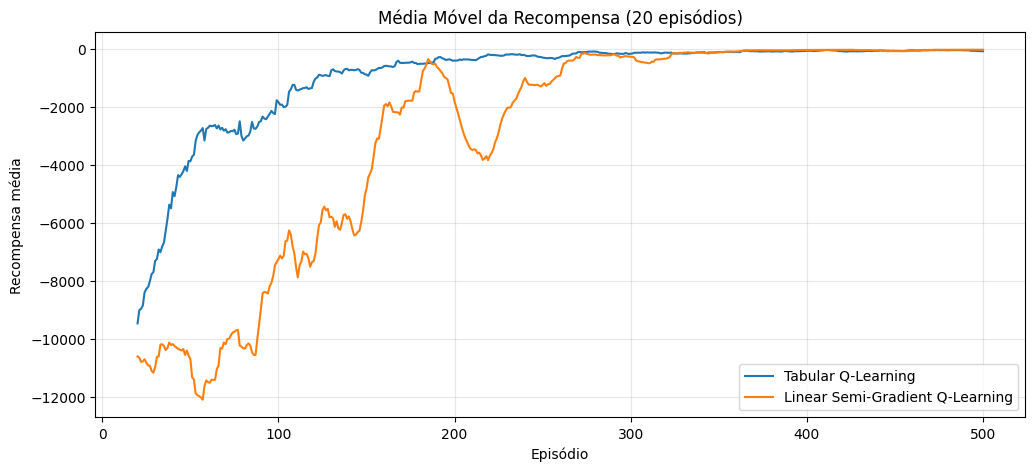

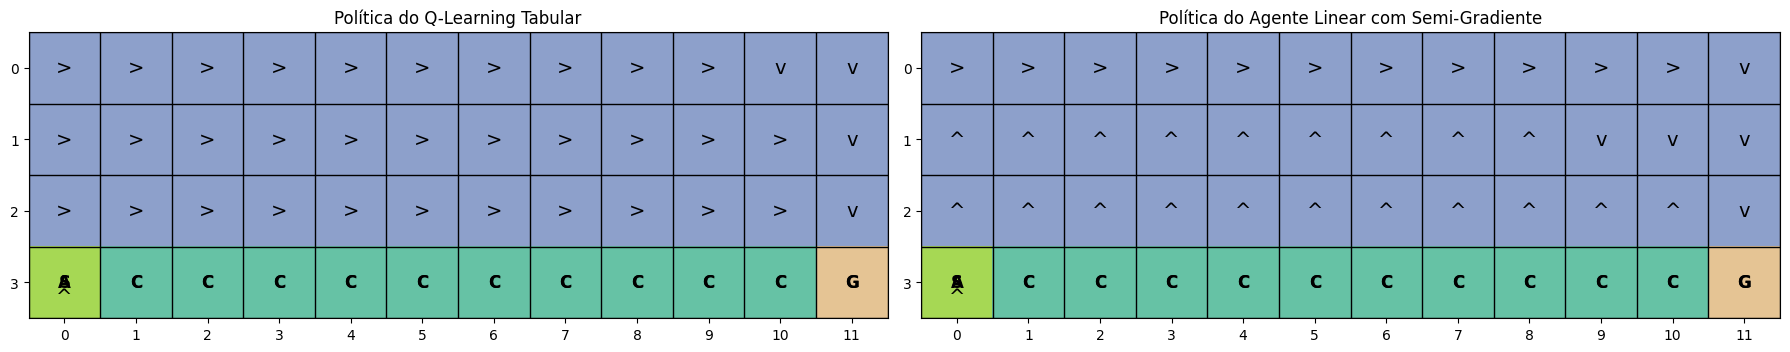

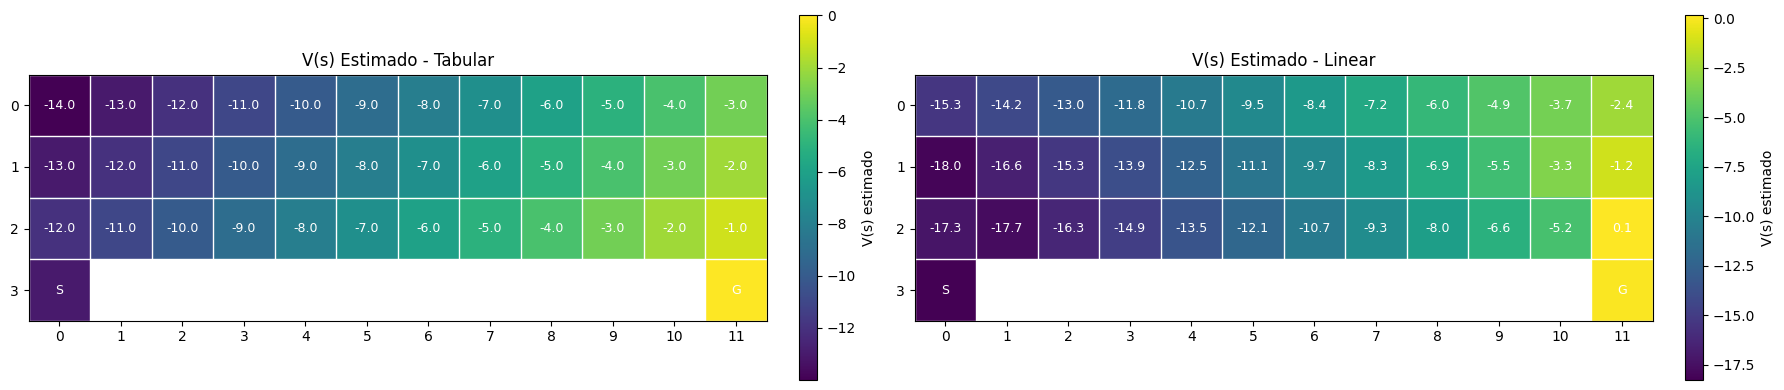

In [45]:
plot_combined_learning_curve(tabular_history, linear_history)
plt.show()

plot_policy_comparison(tabular_agent, linear_agent)
plt.show()

plot_value_heatmap_comparison(tabular_agent, linear_agent)
plt.show()

## Conclusão Técnica

A implementação atende ao núcleo da atividade: o ambiente foi construído do zero, o agente tabular foi usado como baseline, o agente com aproximação linear implementou `Q(s,a,w) = w^T phi(s,a)` com atualização semi-gradiente, e os dois foram comparados por métricas, políticas e funções de valor.

O Q-Learning tabular é mais adequado para este grid pequeno porque consegue armazenar valores específicos para cada estado e ação. Já a aproximação linear demonstra a transição para métodos com função parametrizada: ela reduz a dependência de uma tabela explícita e permite generalização, mas exige uma boa escolha de features e cuidados de estabilidade.

A atividade também exige um vídeo explicativo de 2 a 5 minutos. O roteiro do vídeo não foi incluído aqui por escolha de escopo, mas os gráficos, resultados e interpretações deste notebook fornecem os elementos técnicos necessários para essa apresentação.